<a href="https://colab.research.google.com/github/Muntaha369/Waste-Classifier/blob/main/Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

!pip install tensorflow # Install tensorflow if not already installed
from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them
from tensorflow.keras.layers import GlobalAveragePooling2D    # GlobalAveragePooling2D reduces size

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models
from tensorflow.keras.utils import image_dataset_from_directory  # converts image into 2d array

In [27]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("phenomsg/waste-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'waste-classification' dataset.
Path to dataset files: /kaggle/input/waste-classification


In [28]:
waste_dataset = image_dataset_from_directory(
    f"{path}",
    image_size=(128, 128),
    batch_size=32
)

Found 2902 files belonging to 4 classes.


In [29]:
# you can't directly access image like waste_dataset[0] because tensorflow converted it into a batch not a dict or a tuples

# To access a specific image it's better to itterate over a batchsize
for images, labels in waste_dataset.take(1):
    print("Shape of images batch:", images.shape)
    print("Shape of labels batch:", labels.shape)
    print("Example labels (first 5):")
    print(labels[:5].numpy())

#Anoter way to iterate over a batch
# images, labels = next(iter(waste_dataset)) # iter  --> turns waste_dataset into an iterator we can pull batches from
                                             # next  --> grabs the next batch; since our Dataset returns (image, label) pairs, each batch here comes out as a tuple: (images, labels)

# print(images[0]) # this is a particular image from a batch

print("\nClass Names:")
print(waste_dataset.class_names)

Shape of images batch: (32, 128, 128, 3)
Shape of labels batch: (32,)
Example labels (first 5):
[0 0 1 1 2]

Class Names:
['Hazardous', 'Non-Recyclable', 'Organic', 'Recyclable']


In [30]:
images, labels = next(iter(waste_dataset))

In [31]:
print(images.shape)
print(labels.shape)

(32, 128, 128, 3)
(32,)


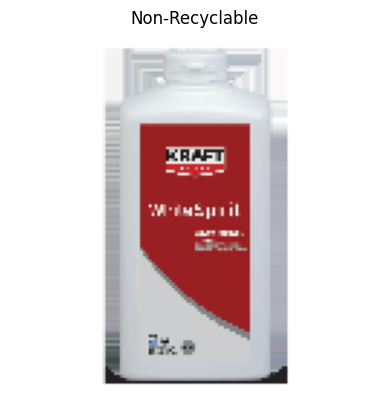

In [32]:
plt.imshow(images[31].numpy().astype("uint8")) # Converts the first TensorFlow image to a NumPy uint8 array (uint8 converts numpy array of floats to interger) and displays it
plt.title(waste_dataset.class_names[labels[0]])
plt.axis("off")
plt.show()

In [33]:
val_split = 0.2
len_dataset = len(waste_dataset)
test_batches = int(val_split * len_dataset)

train_ds = waste_dataset.skip(test_batches)
test_ds = waste_dataset.take(test_batches)

print(f"Number of training batches: {len(train_ds)}")
print(f"Number of validation batches: {len(test_ds)}")

Number of training batches: 73
Number of validation batches: 18


In [34]:
categories = waste_dataset.class_names
classes_count = {cat: 0 for cat in categories}
for i in labels.numpy(): # Convert labels EagerTensor to NumPy array for easier iteration
    class_name = categories[i]
    classes_count[class_name] += 1
print(classes_count)

{'Hazardous': 7, 'Non-Recyclable': 15, 'Organic': 7, 'Recyclable': 3}


In [36]:
# overall_classes_count = {cat: 0 for cat in waste_dataset.class_names}

# for _, labels_batch in waste_dataset:
#     for label_val in labels_batch.numpy():
#         class_name = waste_dataset.class_names[label_val]
#         overall_classes_count[class_name] += 1

# print("Overall Class Distribution:")
# print(overall_classes_count)

In [37]:
total_samples = sum(overall_classes_count.values())
num_classes = len(overall_classes_count)

class_weights = {}
for class_name, count in overall_classes_count.items():
    class_weights[waste_dataset.class_names.index(class_name)] = total_samples / (num_classes * count)

print("Calculated Class Weights:")
print(class_weights)

Calculated Class Weights:
{0: 0.7593818984547461, 1: 1.126022913256956, 2: 1.1008, 3: 1.1278688524590164}


2336

In [ ]:
# Re-define and re-compile the model to ensure the input shape and output units are updated
perceptron = Sequential([
    Flatten(input_shape=(128, 128, 3)),
    Dense(len(waste_dataset.class_names), activation="softmax")
])
perceptron.compile(optimizer="sgd", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_percp = perceptron.fit(train_ds, epochs=5, batch_size=32, validation_data=(test_ds), verbose=1)

Epoch 1/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - accuracy: 0.2640 - loss: 3685095.5000 - val_accuracy: 0.2170 - val_loss: 4579968.0000
Epoch 2/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.2782 - loss: 3582278.5000 - val_accuracy: 0.3264 - val_loss: 4239298.0000
Epoch 3/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - accuracy: 0.3005 - loss: 3073803.2500 - val_accuracy: 0.3333 - val_loss: 5054638.0000
Epoch 4/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 14s 143ms/step - accuracy: 0.3070 - loss: 3033311.0000 - val_accuracy: 0.4410 - val_loss: 2831267.7500
Epoch 5/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - accuracy: 0.3392 - loss: 2496055.7500 - val_accuracy: 0.2587 - val_loss: 2846210.5000


In [ ]:
acc_percp = perceptron.evaluate( test_ds, verbose=0)[1]

acc_percp

0.2725694477558136

In [ ]:
ann = Sequential([
    Flatten(input_shape=(128,128, 3)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(len(waste_dataset.class_names), activation="softmax")
])

ann.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_ann = ann.fit(train_ds, epochs=5, batch_size=32, validation_data=(test_ds), verbose=1)

Epoch 1/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 18s 198ms/step - accuracy: 0.2786 - loss: 1376.4102 - val_accuracy: 0.3299 - val_loss: 1181.6432
Epoch 2/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 16s 187ms/step - accuracy: 0.3108 - loss: 826.1862 - val_accuracy: 0.3281 - val_loss: 507.7481
Epoch 3/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 16s 194ms/step - accuracy: 0.3543 - loss: 684.7703 - val_accuracy: 0.4479 - val_loss: 136.6702
Epoch 4/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 16s 184ms/step - accuracy: 0.3422 - loss: 636.8555 - val_accuracy: 0.2951 - val_loss: 363.2975
Epoch 5/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.3942 - loss: 343.0824 - val_accuracy: 0.4201 - val_loss: 150.2394


In [ ]:
acc_ann = ann.evaluate(test_ds,verbose=0)[1]

acc_ann

0.3993055522441864

### Building a Convolutional Neural Network (CNN) Model

CNNs are particularly effective for image data. This model will include convolutional layers for feature extraction, pooling layers for dimensionality reduction, and dense layers for classification.

In [ ]:
cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(waste_dataset.class_names), activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(cnn.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

None


Now, let's train our CNN model. We'll use the same training and validation datasets as before.

In [ ]:
history_cnn = cnn.fit(train_ds, epochs=10, validation_data=test_ds, verbose=1)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 485ms/step - accuracy: 0.3121 - loss: 24.8672 - val_accuracy: 0.3490 - val_loss: 1.3755
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 484ms/step - accuracy: 0.3349 - loss: 1.3523 - val_accuracy: 0.3698 - val_loss: 1.3745
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 492ms/step - accuracy: 0.3646 - loss: 1.3042 - val_accuracy: 0.3663 - val_loss: 1.3900
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 501ms/step - accuracy: 0.3938 - loss: 1.2526 - val_accuracy: 0.3837 - val_loss: 1.3513
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 487ms/step - accuracy: 0.4566 - loss: 1.1540 - val_accuracy: 0.3785 - val_loss: 1.4353
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 487ms/step - accuracy: 0.5224 - loss: 1.0629 - val_accuracy: 0.4340 - val_loss: 1.3970
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 493ms/step - accuracy: 0.5813 - loss: 0.9191 - val_accuracy: 0.4167 - val_loss: 1.6137
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 492ms/step - accuracy: 0.6268 - loss: 0.8444 - val_acc

After training, we will evaluate the CNN's performance on the test set.

In [ ]:
acc_cnn = cnn.evaluate(test_ds, verbose=0)[1]
print(f"CNN Test Accuracy: {acc_cnn:.4f}")

CNN Test Accuracy: 0.4809


### Retraining the CNN Model with More Epochs

To further improve the model's accuracy, let's train the CNN for more epochs. This can help the model converge better and capture more complex patterns in the data.

In [ ]:
# Continue training the existing cnn model for more epochs
history_cnn_extended = cnn.fit(train_ds, epochs=10, validation_data=test_ds, verbose=1)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 474ms/step - accuracy: 0.7326 - loss: 0.6373 - val_accuracy: 0.5712 - val_loss: 1.5046
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 500ms/step - accuracy: 0.7769 - loss: 0.5748 - val_accuracy: 0.5608 - val_loss: 1.5558
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 484ms/step - accuracy: 0.7975 - loss: 0.5082 - val_accuracy: 0.5747 - val_loss: 1.4653
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 487ms/step - accuracy: 0.8108 - loss: 0.5086 - val_accuracy: 0.6181 - val_loss: 1.4865
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 491ms/step - accuracy: 0.8310 - loss: 0.4738 - val_accuracy: 0.6372 - val_loss: 1.3588
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 492ms/step - accuracy: 0.8495 - loss: 0.3911 - val_accuracy: 0.6250 - val_loss: 1.3204
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 485ms/step - accuracy: 0.8491 - loss: 0.4031 - val_accuracy: 0.6684 - val_loss: 1.2112
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 472ms/step - accuracy: 0.8706 - loss: 0.3423 - val_accu

Now, let's evaluate the CNN's performance after extended training.

In [ ]:
acc_cnn_extended = cnn.evaluate(test_ds, verbose=0)[1]
print(f"CNN Test Accuracy after extended training: {acc_cnn_extended:.4f}")

CNN Test Accuracy after extended training: 0.6615


### Implementing Data Augmentation

Data augmentation artificially increases the size of the training dataset by applying random transformations to the images. This helps the model generalize better and reduces overfitting.

In [ ]:
from tensorflow.keras import layers

data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

Now, let's create a new CNN model that incorporates these data augmentation layers at the beginning. This model will be trained from scratch with the augmented data.

In [ ]:
cnn_augmented = Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(128, 128, 3)), # Rescale input to [0,1] range
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(waste_dataset.class_names), activation='softmax')
])

cnn_augmented.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(cnn_augmented.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Let's train this new CNN model with data augmentation for 20 epochs.

In [ ]:
history_cnn_augmented = cnn_augmented.fit(train_ds, epochs=20, validation_data=test_ds, verbose=1)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 509ms/step - accuracy: 0.3457 - loss: 1.3682 - val_accuracy: 0.4080 - val_loss: 1.2851
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 514ms/step - accuracy: 0.4033 - loss: 1.2819 - val_accuracy: 0.4323 - val_loss: 1.2392
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 524ms/step - accuracy: 0.4127 - loss: 1.2639 - val_accuracy: 0.4358 - val_loss: 1.2304
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 536ms/step - accuracy: 0.4175 - loss: 1.2539 - val_accuracy: 0.3837 - val_loss: 1.3205
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 523ms/step - accuracy: 0.4248 - loss: 1.2461 - val_accuracy: 0.4288 - val_loss: 1.2374
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 517ms/step - accuracy: 0.4282 - loss: 1.2288 - val_accuracy: 0.3785 - val_loss: 1.3342
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 527ms/step - accuracy: 0.4536 - loss: 1.2175 - val_accuracy: 0.4757 - val_loss: 1.1784
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 515ms/step - accuracy: 0.4561 - loss: 1.2053 - val_accu

Finally, let's evaluate the performance of the CNN model with data augmentation on the test set.

In [ ]:
acc_cnn_augmented = cnn_augmented.evaluate(test_ds, verbose=0)[1]
print(f"CNN Test Accuracy with Data Augmentation: {acc_cnn_augmented:.4f}")

CNN Test Accuracy with Data Augmentation: 0.4635


### Building a Deeper CNN Model

To further enhance the model's learning capabilities, let's create a deeper CNN by adding more convolutional layers and increasing the number of filters. This can help the model extract more intricate features from the images.

In [38]:
cnn_deeper = Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)), # Rescale input to [0,1] range
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(256, (3, 3), activation='relu'), # Added layer
    MaxPooling2D((2, 2)),
    # Conv2D(512, (3, 3), activation='relu'), # Added layer
    # MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'), # Increased units
    Dense(len(waste_dataset.class_names), activation='softmax')
])

cnn_deeper.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(cnn_deeper.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,748,996 (10.49 MB)

 Trainable params: 2,748,996 (10.49 MB)

 Non-trainable params: 0 (0.00 B)

None


Now, let's train this deeper CNN model for 20 epochs, similar to our previous attempts.

In [39]:
import tensorflow as tf

def add_sample_weights(image, label):
    # Convert the class_weights dictionary to a TensorFlow constant tensor
    # The keys of class_weights are already integer class indices (0, 1, 2, 3).
    weights_tensor = tf.constant([class_weights[i] for i in sorted(class_weights.keys())], dtype=tf.float32)
    # Use tf.gather to select the appropriate weight for each label
    sample_weight = tf.gather(weights_tensor, label)
    return image, label, sample_weight

# Apply the mapping to both train_ds and test_ds to include sample weights
train_ds_weighted = train_ds.map(add_sample_weights)
test_ds_weighted = test_ds.map(add_sample_weights)

# Train the model with the weighted datasets
history_cnn_deeper = cnn_deeper.fit(train_ds_weighted, epochs=30, validation_data=test_ds_weighted, verbose=1)

Epoch 1/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 48s 499ms/step - accuracy: 0.3070 - loss: 1.3783 - val_accuracy: 0.3368 - val_loss: 1.3576
Epoch 2/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 77s 496ms/step - accuracy: 0.3375 - loss: 1.3016 - val_accuracy: 0.3594 - val_loss: 1.2685
Epoch 3/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 430ms/step - accuracy: 0.3727 - loss: 1.2685 - val_accuracy: 0.3958 - val_loss: 1.2441
Epoch 4/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 46s 497ms/step - accuracy: 0.4140 - loss: 1.2461 - val_accuracy: 0.4167 - val_loss: 1.2258
Epoch 5/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 449ms/step - accuracy: 0.4261 - loss: 1.2499 - val_accuracy: 0.4132 - val_loss: 1.2668
Epoch 6/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 493ms/step - accuracy: 0.4316 - loss: 1.2340 - val_accuracy: 0.3872 - val_loss: 1.2371
Epoch 7/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 466ms/step - accuracy: 0.4643 - loss: 1.1994 - val_accuracy: 0.4688 - val_loss: 1.2009
Epoch 8/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 83s 491ms/step - accuracy: 0.4759 - loss: 1.1653 - val_accu

Finally, we will evaluate the performance of our deeper CNN model on the test set.

In [40]:
acc_cnn_deeper = cnn_deeper.evaluate(test_ds, verbose=0)[1]
print(f"Deeper CNN Test Accuracy: {acc_cnn_deeper:.4f}")

Deeper CNN Test Accuracy: 0.8559


### Adding Dropout for Regularization

To prevent overfitting and further improve generalization, we will add Dropout layers to our deeper CNN model. Dropout randomly sets a fraction of input units to zero during training, which helps in creating a more robust model.

In [ ]:


cnn_deeper_dropout = Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # Added Dropout
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # Added Dropout
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # Added Dropout
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5), # Added Dropout to the dense layer
    Dense(len(waste_dataset.class_names), activation='softmax')
])

cnn_deeper_dropout.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(cnn_deeper_dropout.summary())

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,748,996 (10.49 MB)

 Trainable params: 2,748,996 (10.49 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
cnn_deeper_dropout = Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # Added Dropout
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # Added Dropout
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25), # Added Dropout
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5), # Added Dropout to the dense layer
    Dense(len(waste_dataset.class_names), activation='softmax')
])

cnn_deeper_dropout.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(cnn_deeper_dropout.summary())

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,748,996 (10.49 MB)

 Trainable params: 2,748,996 (10.49 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
history_cnn_deeper_dropout = cnn_deeper_dropout.fit(train_ds, epochs=20, validation_data=test_ds, verbose=1)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 55s 539ms/step - accuracy: 0.3138 - loss: 1.4326 - val_accuracy: 0.3264 - val_loss: 1.3624
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 449ms/step - accuracy: 0.3392 - loss: 1.3546 - val_accuracy: 0.3872 - val_loss: 1.3416
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 496ms/step - accuracy: 0.3985 - loss: 1.2996 - val_accuracy: 0.4115 - val_loss: 1.3031
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 446ms/step - accuracy: 0.4144 - loss: 1.2746 - val_accuracy: 0.4219 - val_loss: 1.2653
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 471ms/step - accuracy: 0.4222 - loss: 1.2642 - val_accuracy: 0.4010 - val_loss: 1.2927
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 445ms/step - accuracy: 0.4140 - loss: 1.2599 - val_accuracy: 0.4201 - val_loss: 1.2611
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 39s 437ms/step - accuracy: 0.4261 - loss: 1.2504 - val_accuracy: 0.4288 - val_loss: 1.2294
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 507ms/step - accuracy: 0.4183 - loss: 1.2507 - val_accu

In [ ]:
acc_cnn_deeper_dropout = cnn_deeper_dropout.evaluate(test_ds, verbose=0)[1]
print(f"Deeper CNN Test Accuracy with Dropout: {acc_cnn_deeper_dropout:.4f}")

Deeper CNN Test Accuracy with Dropout: 0.1788


In [ ]:
cnn_deeper_dropout_adjusted = Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.1), # Adjusted Dropout rate
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.1), # Adjusted Dropout rate
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.1), # Adjusted Dropout rate
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3), # Adjusted Dropout rate for dense layer
    Dense(len(waste_dataset.class_names), activation='softmax')
])

cnn_deeper_dropout_adjusted.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(cnn_deeper_dropout_adjusted.summary())

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,748,996 (10.49 MB)

 Trainable params: 2,748,996 (10.49 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
history_cnn_deeper_dropout_adjusted = cnn_deeper_dropout_adjusted.fit(train_ds, epochs=20, validation_data=test_ds, verbose=1)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 50s 489ms/step - accuracy: 0.3160 - loss: 1.3873 - val_accuracy: 0.3698 - val_loss: 1.3298
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 434ms/step - accuracy: 0.3856 - loss: 1.3107 - val_accuracy: 0.3767 - val_loss: 1.3401
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 445ms/step - accuracy: 0.3968 - loss: 1.2967 - val_accuracy: 0.4184 - val_loss: 1.2574
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 452ms/step - accuracy: 0.4071 - loss: 1.2635 - val_accuracy: 0.4149 - val_loss: 1.2846
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 443ms/step - accuracy: 0.4037 - loss: 1.2716 - val_accuracy: 0.4219 - val_loss: 1.2712
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 493ms/step - accuracy: 0.4170 - loss: 1.2641 - val_accuracy: 0.4427 - val_loss: 1.2617
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 420ms/step - accuracy: 0.4308 - loss: 1.2454 - val_accuracy: 0.4358 - val_loss: 1.2403
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 487ms/step - accuracy: 0.4295 - loss: 1.2378 - val_accu

In [ ]:
acc_cnn_deeper_dropout_adjusted = cnn_deeper_dropout_adjusted.evaluate(test_ds, verbose=0)[1]
print(f"Deeper CNN Test Accuracy with Adjusted Dropout: {acc_cnn_deeper_dropout_adjusted:.4f}")

Deeper CNN Test Accuracy with Adjusted Dropout: 0.6024
